
GPU CHECK
CUDA: True
GPU: NVIDIA RTX A5000
Memory: 25.76 GB

CONFIG: {'num_epochs': 100, 'learning_rate': 0.001, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_decay': 0.999, 'epsilon_min': 0.01, 'batch_size': 64, 'buffer_size': 10000, 'target_update_freq': 10, 'device': None, 'show_plots': True}

DDQN TRAINING - EV CHARGING STATION SELECTION
Device: cuda | Epochs: 100 | Batch: 64
Results: results\2025-12-02_21-16-38

✓ Loaded dataset with 60 instances
✓ Loaded fleet data with 100 vehicles
✓ Computed normalization constants

DDQN Agent Initialization
Using device: cuda
GPU: NVIDIA RTX A5000
GPU Memory: 25.76 GB
CUDA Version: 12.1

Initializing DDQN Architecture on device: cuda
Using default vehicle input dimension: 7 (x, y, battery, max_battery, time, dist_next, remaining_dist)
✓ All networks successfully moved to cuda
Total trainable parameters: 114,023


C:\Users\ayoub\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\module.py:1159: UserWarning: expandable_segments not supported on this platform (Triggered internally at ..\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


Selected instances:
  C: ['C1_10_1.txt', 'C1_10_10.txt', 'C1_10_2.txt', 'C1_10_3.txt', 'C1_10_4.txt', 'C1_10_5.txt', 'C1_10_6.txt', 'C1_10_7.txt', 'C1_10_8.txt', 'C1_10_9.txt']
  R: ['R1_10_1.txt', 'R1_10_10.txt', 'R1_10_2.txt', 'R1_10_3.txt', 'R1_10_4.txt', 'R1_10_5.txt', 'R1_10_6.txt', 'R1_10_7.txt', 'R1_10_8.txt', 'R1_10_9.txt']
  RC: ['RC1_10_1.txt', 'RC1_10_10.txt', 'RC1_10_2.txt', 'RC1_10_3.txt', 'RC1_10_4.txt', 'RC1_10_5.txt', 'RC1_10_6.txt', 'RC1_10_7.txt', 'RC1_10_8.txt', 'RC1_10_9.txt']


EPOCH 1/100
Training: ['R:R1_10_8.txt', 'RC:RC1_10_1.txt', 'C:C1_10_9.txt']

R - R1_10_8.txt (95 vehicles)

RC - RC1_10_1.txt (93 vehicles)

C - C1_10_9.txt (87 vehicles)

--------------------------------------------------------------------------------
EPOCH 1: Mean=-5.83 +/- 1.91 | [-9.99, -1.47] | eps=0.7595 | 14.1min

EPOCH 2/100
Training: ['C:C1_10_7.txt', 'R:R1_10_5.txt', 'RC:RC1_10_6.txt']

C - C1_10_7.txt (91 vehicles)

R - R1_10_5.txt (94 vehicles)

RC - RC1_10_6.txt (93 vehicles)

-

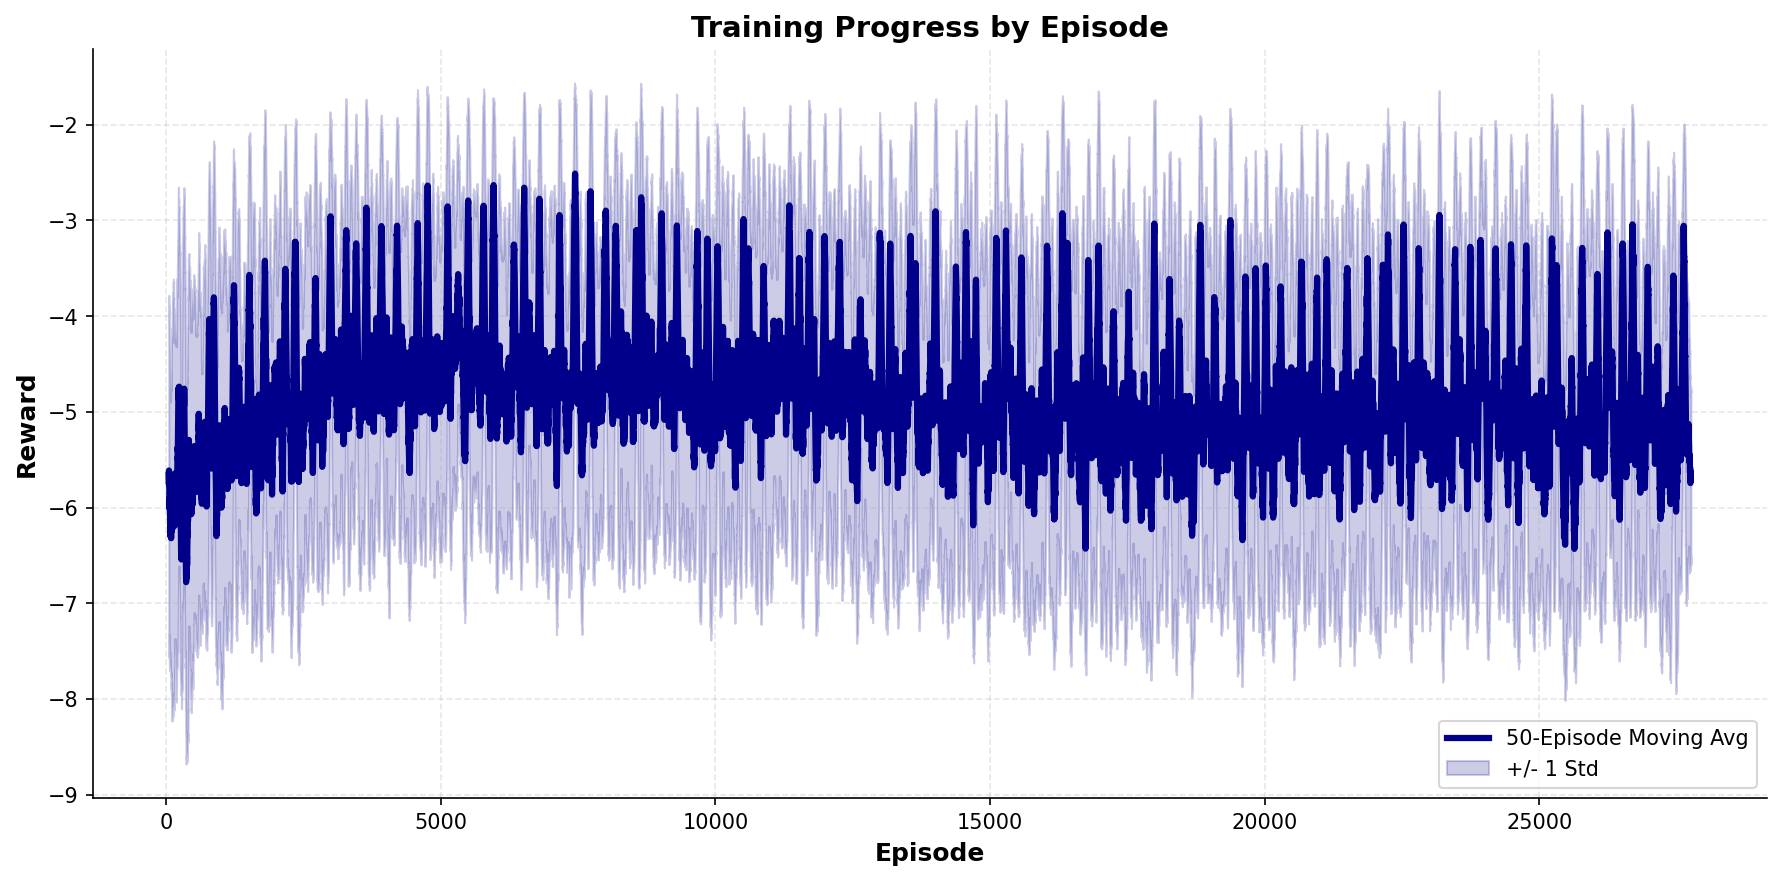

Creating: 2_reward_by_epoch.png ...
  [OK] Saved


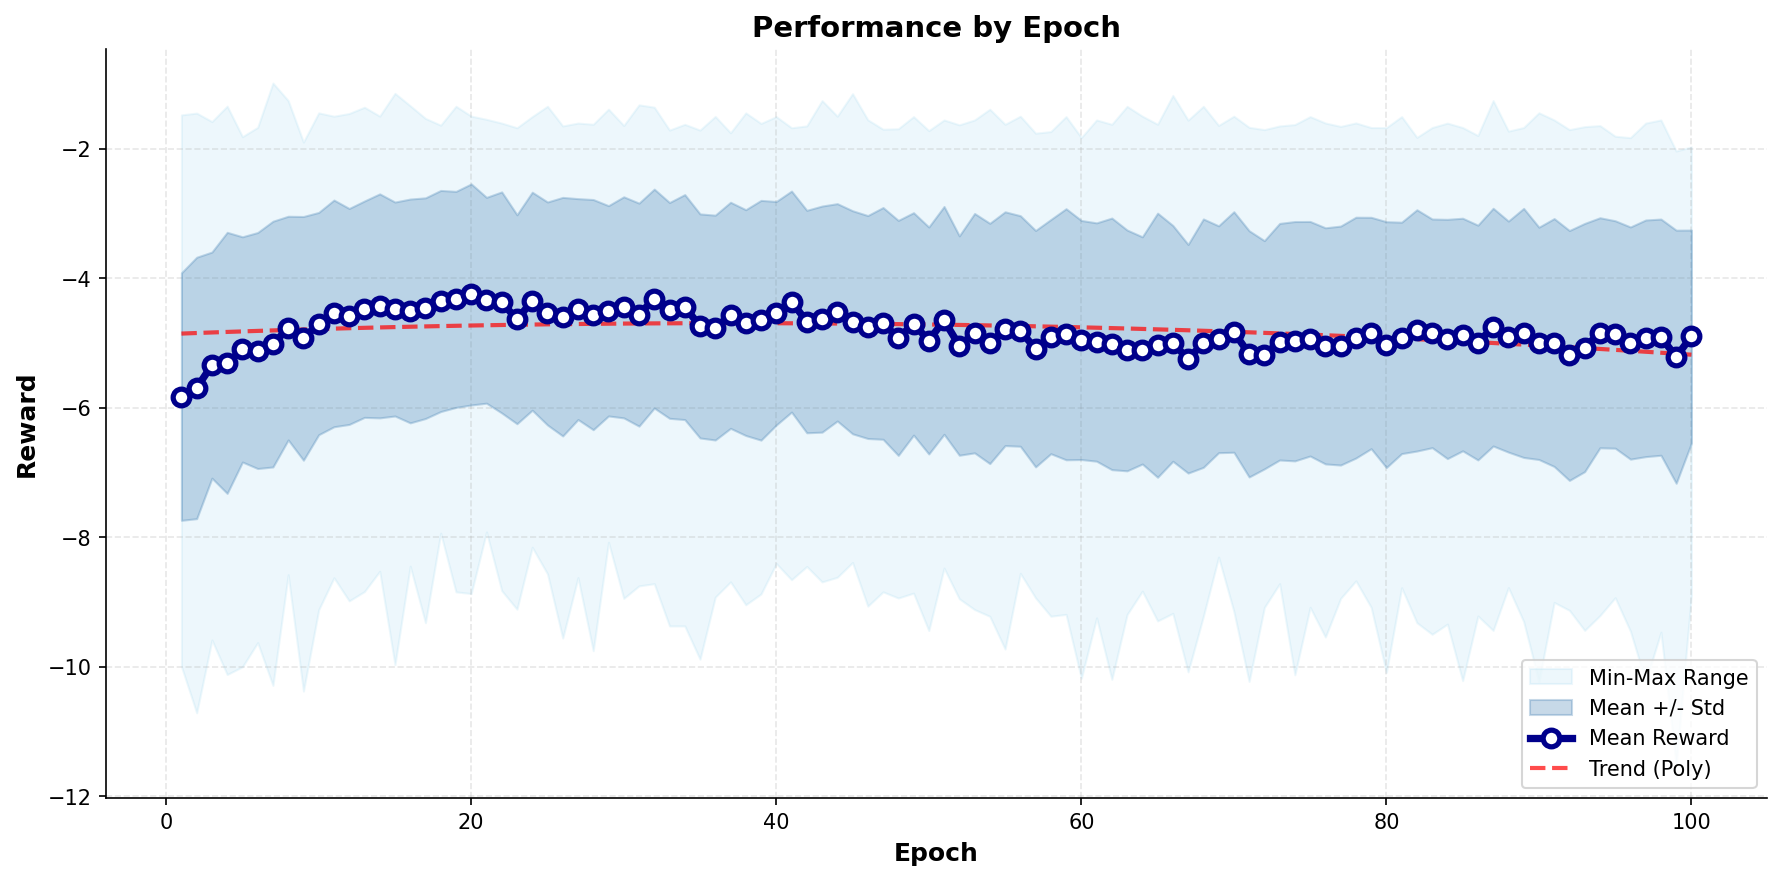

Creating: 3_station_loss.png ...
  [OK] Saved


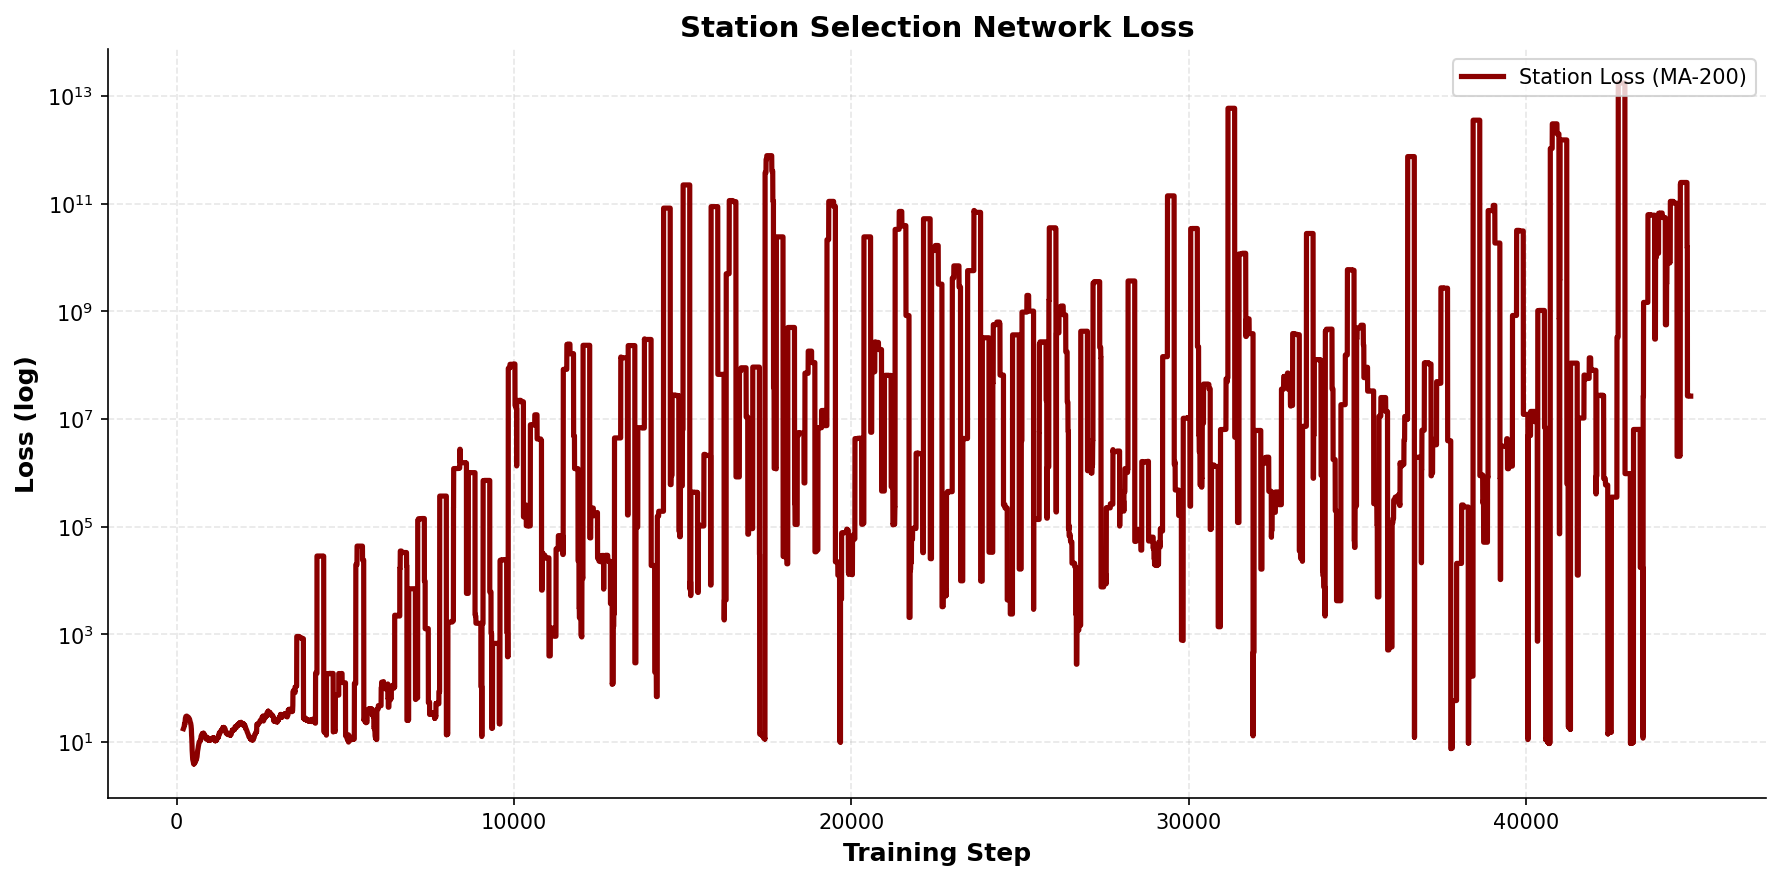

Creating: 4_portion_loss.png ...
  [OK] Saved


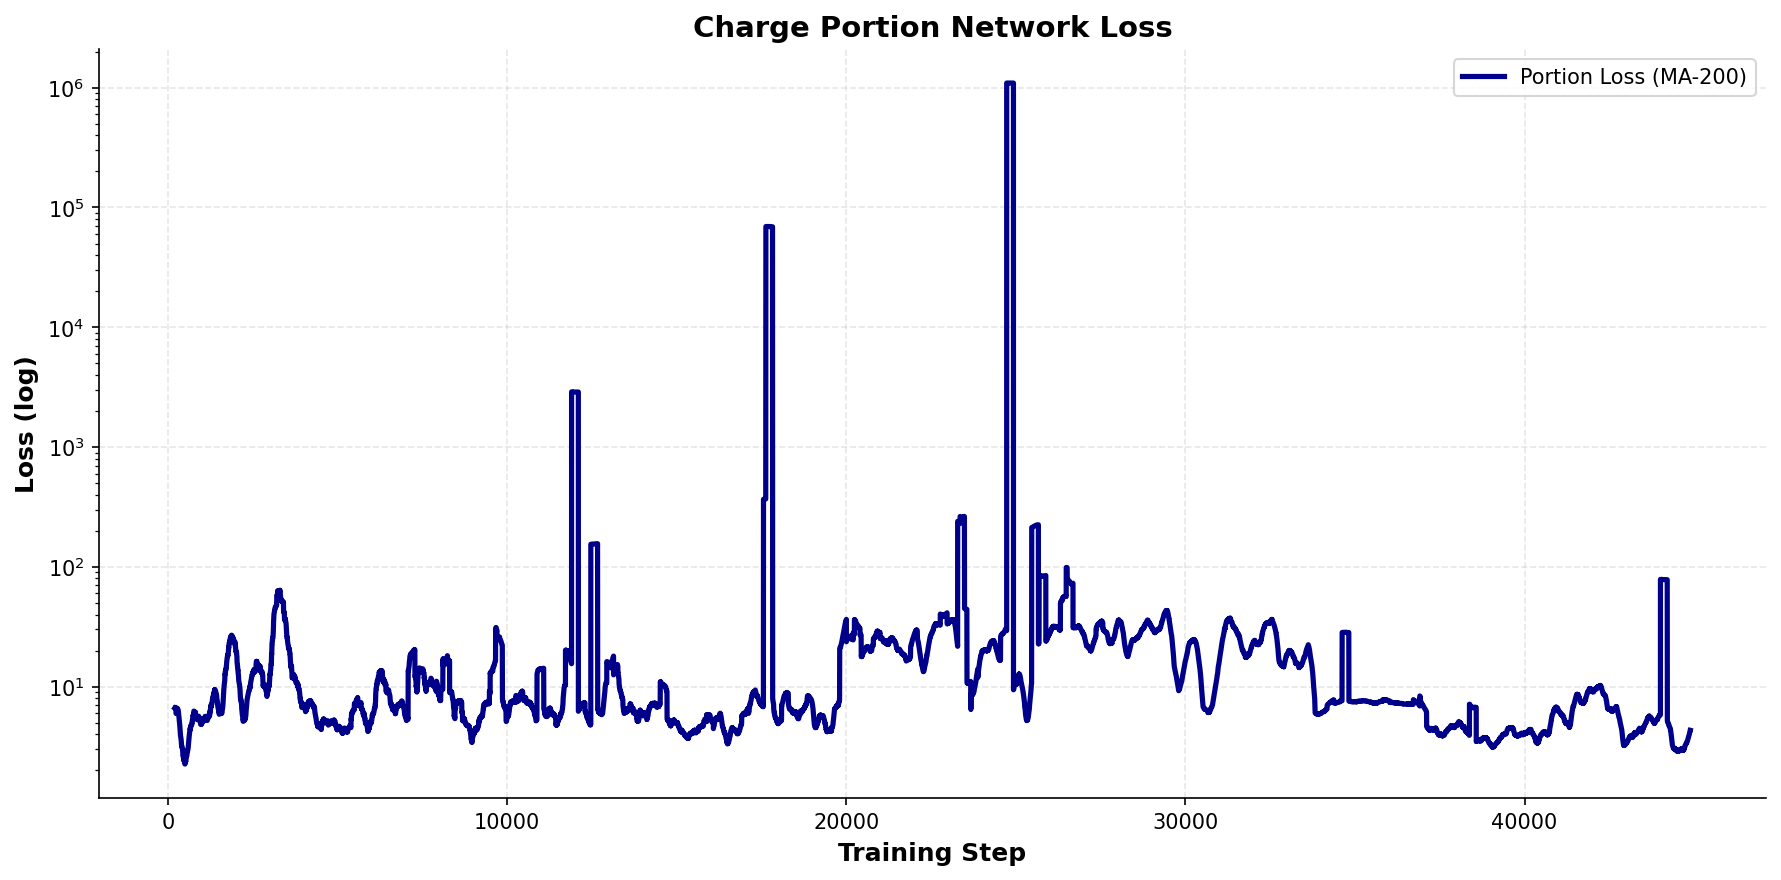

Creating: 5_epsilon_decay.png ...
  [OK] Saved


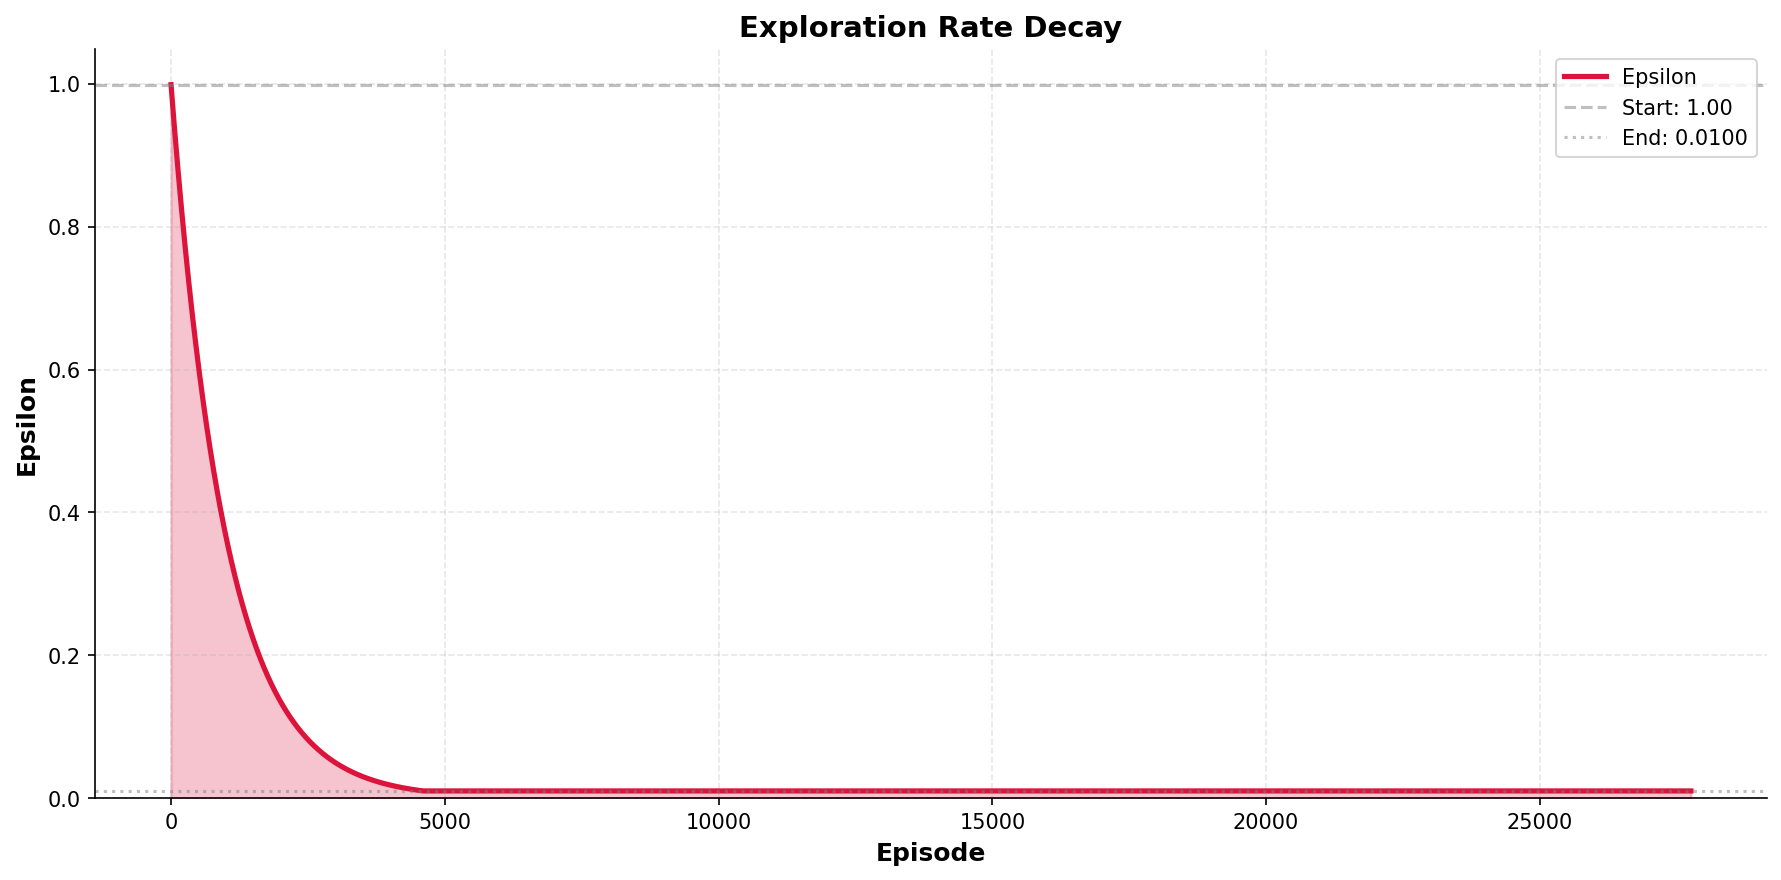

--------------------------------------------------------------------------------
Saved 5/5 plots to: results\2025-12-02_21-16-38


DONE! Results: results\2025-12-02_21-16-38
  Plots: ['1_reward_by_episode.png', '2_reward_by_epoch.png', '3_station_loss.png', '4_portion_loss.png', '5_epsilon_decay.png']


In [1]:
# ============================================================
# MUST BE FIRST - Before any other imports
# ============================================================
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # Fix OMP Error #15

import matplotlib
matplotlib.use('Agg')

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# ============================================================
# Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from data_manager import DataManager
from environment import Environment
from ddqn_agent import DDQNAgent
import torch
import time
from datetime import datetime
import random
import gc

# For displaying images in Jupyter
try:
    from IPython.display import display, Image as IPImage
    IN_JUPYTER = True
except ImportError:
    IN_JUPYTER = False

# Initial cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# GPU Check
print("\n" + "="*80)
print("GPU CHECK")
print("="*80)
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("="*80 + "\n")


# ============================================================
# Helper Functions
# ============================================================
def get_instance_type(instance_id: str) -> str:
    instance_id = instance_id.upper()
    if instance_id.startswith('RC'): return 'RC'
    if instance_id.startswith('R'): return 'R'
    if instance_id.startswith('C'): return 'C'
    return 'UNKNOWN'


def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def show_image(path):
    if IN_JUPYTER and os.path.exists(path):
        display(IPImage(filename=path))


# ============================================================
# Plotting Function
# ============================================================
def generate_plots(episode_rewards, station_losses, portion_losses, 
                   epsilon_history, epoch_stats, results_dir, show=True):
    """Generate, save, and optionally display all training plots."""
    
    print("\n" + "="*80)
    print("GENERATING PLOTS")
    print("="*80)
    
    saved = []
    
    plt.rcParams.update({
        'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14,
        'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
        'figure.max_open_warning': 0
    })
    
    # ========== 1. REWARD BY EPISODE ==========
    try:
        print("Creating: 1_reward_by_episode.png ...")
        fig, ax = plt.subplots(figsize=(12, 6))
        
        n = len(episode_rewards)
        window = max(1, min(50, n // 5))
        
        if n >= window > 1:
            ma = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
            ma_x = np.arange(window-1, n)
            ax.plot(ma_x, ma, color='darkblue', lw=3, label=f'{window}-Episode Moving Avg')
            
            std = np.array([np.std(episode_rewards[i-window+1:i+1]) for i in range(window-1, n)])
            ax.fill_between(ma_x, ma-std, ma+std, alpha=0.2, color='darkblue', label='+/- 1 Std')
        else:
            ax.plot(episode_rewards, color='darkblue', lw=2, label='Reward')
        
        ax.set_xlabel('Episode', fontweight='bold')
        ax.set_ylabel('Reward', fontweight='bold')
        ax.set_title('Training Progress by Episode', fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, ls='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        path = os.path.join(results_dir, '1_reward_by_episode.png')
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
        saved.append(path)
        print(f"  [OK] Saved")
        plt.close(fig)
        if show: show_image(path)
    except Exception as e:
        print(f"  [ERROR] {e}")
        plt.close('all')
    
    cleanup()
    
    # ========== 2. REWARD BY EPOCH (with min-max and std shadows) ==========
    try:
        print("Creating: 2_reward_by_epoch.png ...")
        fig, ax = plt.subplots(figsize=(12, 6))
        
        epochs = np.array([s['epoch'] for s in epoch_stats])
        means = np.array([s['mean_reward'] for s in epoch_stats])
        stds = np.array([s['std_reward'] for s in epoch_stats])
        mins = np.array([s['min_reward'] for s in epoch_stats])
        maxs = np.array([s['max_reward'] for s in epoch_stats])
        
        # Layer 1: Min-Max range (lightest)
        ax.fill_between(epochs, mins, maxs, alpha=0.15, color='skyblue', 
                        label='Min-Max Range', zorder=1)
        
        # Layer 2: Mean +/- Std (medium)
        ax.fill_between(epochs, means-stds, means+stds,
                        alpha=0.3, color='steelblue', label='Mean +/- Std', zorder=2)
        
        # Layer 3: Mean line (bold with markers)
        ax.plot(epochs, means, color='darkblue', lw=3.5, marker='o', 
                markersize=8, markerfacecolor='white', markeredgewidth=2.5, 
                markeredgecolor='darkblue', label='Mean Reward', zorder=3)
        
        # Trend line
        if len(epochs) > 3:
            z = np.polyfit(epochs, means, 2)
            p = np.poly1d(z)
            ax.plot(epochs, p(epochs), color='red', lw=2, ls='--', 
                    alpha=0.7, label='Trend (Poly)', zorder=2)
        
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel('Reward', fontweight='bold')
        ax.set_title('Performance by Epoch', fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, ls='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        path = os.path.join(results_dir, '2_reward_by_epoch.png')
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
        saved.append(path)
        print(f"  [OK] Saved")
        plt.close(fig)
        if show: show_image(path)
    except Exception as e:
        print(f"  [ERROR] {e}")
        plt.close('all')
    
    cleanup()
    
    # ========== 3. STATION LOSS ==========
    try:
        print("Creating: 3_station_loss.png ...")
        fig, ax = plt.subplots(figsize=(12, 6))
        
        if station_losses:
            n = len(station_losses)
            window = max(1, min(200, n // 5))
            
            if n >= window > 1:
                ma = np.convolve(station_losses, np.ones(window)/window, mode='valid')
                ax.plot(np.arange(window-1, n), ma, color='darkred', lw=2.5, 
                        label=f'Station Loss (MA-{window})')
            else:
                ax.plot(station_losses, color='darkred', lw=1.5, label='Station Loss')
            ax.set_yscale('log')
            ax.legend(loc='upper right')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_xlabel('Training Step', fontweight='bold')
        ax.set_ylabel('Loss (log)', fontweight='bold')
        ax.set_title('Station Selection Network Loss', fontweight='bold')
        ax.grid(True, alpha=0.3, ls='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        path = os.path.join(results_dir, '3_station_loss.png')
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
        saved.append(path)
        print(f"  [OK] Saved")
        plt.close(fig)
        if show: show_image(path)
    except Exception as e:
        print(f"  [ERROR] {e}")
        plt.close('all')
    
    cleanup()
    
    # ========== 4. PORTION LOSS ==========
    try:
        print("Creating: 4_portion_loss.png ...")
        fig, ax = plt.subplots(figsize=(12, 6))
        
        if portion_losses:
            n = len(portion_losses)
            window = max(1, min(200, n // 5))
            
            if n >= window > 1:
                ma = np.convolve(portion_losses, np.ones(window)/window, mode='valid')
                ax.plot(np.arange(window-1, n), ma, color='darkblue', lw=2.5, 
                        label=f'Portion Loss (MA-{window})')
            else:
                ax.plot(portion_losses, color='darkblue', lw=1.5, label='Portion Loss')
            ax.set_yscale('log')
            ax.legend(loc='upper right')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_xlabel('Training Step', fontweight='bold')
        ax.set_ylabel('Loss (log)', fontweight='bold')
        ax.set_title('Charge Portion Network Loss', fontweight='bold')
        ax.grid(True, alpha=0.3, ls='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        path = os.path.join(results_dir, '4_portion_loss.png')
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
        saved.append(path)
        print(f"  [OK] Saved")
        plt.close(fig)
        if show: show_image(path)
    except Exception as e:
        print(f"  [ERROR] {e}")
        plt.close('all')
    
    cleanup()
    
    # ========== 5. EPSILON DECAY ==========
    try:
        print("Creating: 5_epsilon_decay.png ...")
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = np.arange(len(epsilon_history))
        ax.plot(x, epsilon_history, color='crimson', lw=2.5, label='Epsilon')
        ax.fill_between(x, 0, epsilon_history, alpha=0.25, color='crimson')
        ax.axhline(y=epsilon_history[0], color='gray', ls='--', alpha=0.5, label=f'Start: {epsilon_history[0]:.2f}')
        ax.axhline(y=epsilon_history[-1], color='gray', ls=':', alpha=0.5, label=f'End: {epsilon_history[-1]:.4f}')
        
        ax.set_xlabel('Episode', fontweight='bold')
        ax.set_ylabel('Epsilon', fontweight='bold')
        ax.set_title('Exploration Rate Decay', fontweight='bold')
        ax.set_ylim(0, epsilon_history[0] * 1.05)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3, ls='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        path = os.path.join(results_dir, '5_epsilon_decay.png')
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
        saved.append(path)
        print(f"  [OK] Saved")
        plt.close(fig)
        if show: show_image(path)
    except Exception as e:
        print(f"  [ERROR] {e}")
        plt.close('all')
    
    plt.close('all')
    cleanup()
    
    print("-"*80)
    print(f"Saved {len(saved)}/5 plots to: {results_dir}")
    print("="*80 + "\n")
    
    return saved


def regenerate_plots(results_dir, show=True):
    """Regenerate plots from saved data if kernel crashed."""
    
    path = os.path.join(results_dir, 'training_data.npz')
    if not os.path.exists(path):
        print(f"ERROR: {path} not found")
        return []
    
    print(f"Loading: {path}")
    data = np.load(path, allow_pickle=True)
    
    episode_rewards = list(data['episode_rewards'])
    station_losses = list(data['station_losses'])
    portion_losses = list(data['portion_losses'])
    epsilon_history = list(data['epsilon_history'])
    
    # Try to load epoch_stats, reconstruct if not available
    try:
        epoch_stats = list(data['epoch_stats'])
    except:
        epoch_stats = []
        ep_per_epoch = max(1, len(episode_rewards) // 50)
        for i in range(0, len(episode_rewards), ep_per_epoch):
            chunk = episode_rewards[i:i+ep_per_epoch]
            if chunk:
                epoch_stats.append({
                    'epoch': len(epoch_stats) + 1,
                    'mean_reward': np.mean(chunk), 'std_reward': np.std(chunk),
                    'min_reward': np.min(chunk), 'max_reward': np.max(chunk),
                    'epsilon': epsilon_history[min(i+ep_per_epoch-1, len(epsilon_history)-1)]
                })
    
    return generate_plots(episode_rewards, station_losses, portion_losses,
                          epsilon_history, epoch_stats, results_dir, show)


# ============================================================
# Training Function
# ============================================================
def train(num_epochs=20, learning_rate=0.001, gamma=0.99, epsilon_start=1.0,
          epsilon_decay=0.999, epsilon_min=0.01, batch_size=64, buffer_size=10000,
          target_update_freq=10, device=None, show_plots=True):
    
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    results_dir = os.path.join("results", timestamp)
    os.makedirs(results_dir, exist_ok=True)
    
    print("="*80)
    print("DDQN TRAINING - EV CHARGING STATION SELECTION")
    print("="*80)
    print(f"Device: {device} | Epochs: {num_epochs} | Batch: {batch_size}")
    print(f"Results: {results_dir}")
    print("="*80 + "\n")
    
    # Initialize
    start_time = time.time()
    data_manager = DataManager()
    environment = Environment(data_manager)
    
    agent = DDQNAgent(
        learning_rate=learning_rate, gamma=gamma, epsilon=epsilon_start,
        epsilon_decay=epsilon_decay, epsilon_min=epsilon_min, batch_size=batch_size,
        buffer_size=buffer_size, target_update_freq=target_update_freq, device=device
    )
    
    # Categorize instances
    all_instances = data_manager.get_all_instances()
    instances = {'C': {}, 'R': {}, 'RC': {}}
    
    for key, data in all_instances.items():
        itype = get_instance_type(data['instance_id'])
        if itype in instances:
            instances[itype][key] = data
    
    selected = {t: dict(list(v.items())[:15]) for t, v in instances.items()}
    
    print("Selected instances:")
    for t, v in selected.items():
        print(f"  {t}: {[d['instance_id'] for d in v.values()]}")
    print()
    
    # Storage
    episode_rewards, station_losses, portion_losses, epsilon_history, epoch_stats = [], [], [], [], []
    global_ep = 0
    
    # Training loop
    for epoch in range(num_epochs):
        t0 = time.time()
        print("\n" + "="*80)
        print(f"EPOCH {epoch + 1}/{num_epochs}")
        print("="*80)
        
        epoch_instances = [(random.choice(list(selected[t].items())), t) for t in ['C', 'R', 'RC']]
        random.shuffle(epoch_instances)
        
        print("Training:", [f"{t}:{d['instance_id']}" for (_, d), t in epoch_instances])
        
        ep_rewards = []
        
        for (inst_key, inst_data), inst_type in epoch_instances:
            vehicles = data_manager.get_all_vehicles_in_instance(inst_key)
            print(f"\n{inst_type} - {inst_data['instance_id']} ({len(vehicles)} vehicles)")
            
            for v_data in vehicles.values():
                vid = v_data.get('id')
                if not vid:
                    continue
                
                state = environment.reset(inst_key, vid)
                if state is None:
                    continue
                
                reward, steps, done = 0.0, 0, False
                global_ep += 1
                
                while not done and steps < 2:
                    si, pi = agent.select_action(state, training=True)
                    sid = state['station_ids'][si]
                    cp = agent.charge_portions[pi]
                    
                    ns, r, done = environment.step(sid, cp)
                    agent.store_experience(state, si, pi, r, ns, done)
                    
                    if agent.get_buffer_size() >= batch_size:
                        sl, pl = agent.train()
                        station_losses.append(sl)
                        portion_losses.append(pl)
                    
                    state, reward, steps = ns, reward + r, steps + 1
                
                agent.end_episode()
                episode_rewards.append(reward)
                ep_rewards.append(reward)
                epsilon_history.append(agent.get_epsilon())
                
                if global_ep % 5 == 0:
                    cleanup()
        
        # Epoch stats
        stats = {
            'epoch': epoch + 1,
            'mean_reward': np.mean(ep_rewards),
            'std_reward': np.std(ep_rewards),
            'min_reward': np.min(ep_rewards),
            'max_reward': np.max(ep_rewards),
            'epsilon': agent.get_epsilon(),
            'time': time.time() - t0,
            'episode_count': len(ep_rewards)
        }
        epoch_stats.append(stats)
        
        print(f"\n{'-'*80}")
        print(f"EPOCH {epoch+1}: Mean={stats['mean_reward']:.2f} +/- {stats['std_reward']:.2f} | "
              f"[{stats['min_reward']:.2f}, {stats['max_reward']:.2f}] | "
              f"eps={stats['epsilon']:.4f} | {stats['time']/60:.1f}min")
        
        cleanup()
    
    total_time = time.time() - start_time
    
    print("\n" + "="*80)
    print("TRAINING COMPLETE")
    print("="*80)
    print(f"Episodes: {global_ep} | Time: {total_time/60:.1f}min | Final eps: {agent.get_epsilon():.4f}")
    print("="*80 + "\n")
    
    # Save
    print("Saving...")
    agent.save(os.path.join(results_dir, 'model_final'))
    print("  [OK] Model")
    
    # Use encoding='utf-8' to avoid Windows encoding issues
    with open(os.path.join(results_dir, 'config.txt'), 'w', encoding='utf-8') as f:
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Device: {device}\n")
        f.write(f"Epochs: {num_epochs}\n")
        f.write(f"Learning Rate: {learning_rate}\n")
        f.write(f"Gamma: {gamma}\n")
        f.write(f"Epsilon: {epsilon_start} -> {epsilon_min} (decay={epsilon_decay})\n")
        f.write(f"Batch Size: {batch_size}\n")
        f.write(f"Buffer Size: {buffer_size}\n")
        f.write(f"Target Update Freq: {target_update_freq}\n")
    print("  [OK] Config")
    
    with open(os.path.join(results_dir, 'summary.txt'), 'w', encoding='utf-8') as f:
        f.write(f"Total Episodes: {global_ep}\n")
        f.write(f"Total Time: {total_time/60:.1f} min\n")
        f.write(f"Final Epsilon: {agent.get_epsilon():.4f}\n")
        f.write(f"Mean Reward: {np.mean(episode_rewards):.2f} +/- {np.std(episode_rewards):.2f}\n")
        f.write(f"Best Reward: {max(episode_rewards):.2f}\n")
        f.write(f"Worst Reward: {min(episode_rewards):.2f}\n")
        f.write("\n")
        f.write("="*70 + "\n")
        f.write(f"{'Epoch':<8}{'Mean':<12}{'Std':<10}{'Min':<10}{'Max':<10}{'Epsilon':<10}\n")
        f.write("="*70 + "\n")
        for s in epoch_stats:
            f.write(f"{s['epoch']:<8}{s['mean_reward']:<12.2f}{s['std_reward']:<10.2f}"
                   f"{s['min_reward']:<10.2f}{s['max_reward']:<10.2f}{s['epsilon']:<10.4f}\n")
    print("  [OK] Summary")
    
    np.savez(os.path.join(results_dir, 'training_data.npz'),
             episode_rewards=episode_rewards, station_losses=station_losses,
             portion_losses=portion_losses, epsilon_history=epsilon_history,
             epoch_stats=epoch_stats)
    print("  [OK] Data")
    
    cleanup()
    
    saved = generate_plots(episode_rewards, station_losses, portion_losses,
                           epsilon_history, epoch_stats, results_dir, show=show_plots)
    
    return agent, episode_rewards, epoch_stats, saved, results_dir


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    config = {
        'num_epochs': 100,
        'learning_rate': 0.001,
        'gamma': 0.99,
        'epsilon_start': 1.0,
        'epsilon_decay': 0.999,
        'epsilon_min': 0.01,
        'batch_size': 64,
        'buffer_size': 10000,
        'target_update_freq': 10,
        'device': None,
        'show_plots': True
    }
    
    print("="*80)
    print("CONFIG:", config)
    print("="*80 + "\n")
    
    agent, rewards, epoch_stats, saved, results_dir = train(**config)
    
    print("\n" + "="*80)
    print(f"DONE! Results: {results_dir}")
    print(f"  Plots: {[os.path.basename(p) for p in saved]}")
    print("="*80)
    
    if len(saved) < 5:
        print(f"\nTo regenerate: regenerate_plots('{results_dir}')")